# Load Data

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

folders = {'Xela': 'UniTac-NV Dataset Processed/Xela', 'PapillArray': 'UniTac-NV Dataset Processed/PapillArray'}

dataset = {}

def extract_material_info(file_name):
    parts = file_name.split('_')
    geometry = parts[0]  
    material = parts[1] if 'TPU' in parts else 'PLA'  
    return geometry, material

# Load data
for folder_name, folder_path in folders.items():
    dataset[folder_name] = {}
    if os.path.exists(folder_path):  
        for file_name in os.listdir(folder_path):
            if file_name.endswith('.npz'):
                file_path = os.path.join(folder_path, file_name)
                data = np.load(file_path)
                
                # Extract material and geometry information from the file name
                geometry, material = extract_material_info(file_name)
                
                # Store data in a structured format
                dataset[folder_name][file_name] = {
                    'geometry': geometry,
                    'material': material,
                    'times': data['times'],
                    'sensor_matrices_force': data['sensor_matrices_force'],
                    'sensor_matrices_displacement': data['sensor_matrices_displacement'],
                    'ft_values': data['ft_values'],
                    'end_effector_poses': data['end_effector_poses'],
                    # 'selected': data['selected'],
                    # 'angle': data['angle']
                }

# Print a summary of the imported dataset
for folder_name, files in dataset.items():
    print(f"Folder: {folder_name}")
    for file_name, file_data in files.items():
        print(f"  File: {file_name}")
        print(f"    Geometry: {file_data['geometry']}")
        print(f"    Material: {file_data['material']}")
        print(f"    Times Shape: {file_data['times'].shape}")
        print(f"    Sensor Matrices Force Shape: {file_data['sensor_matrices_force'].shape}")
        print(f"    Sensor Matrices Displacement Shape: {file_data['sensor_matrices_displacement'].shape}")
        print(f"    FT Values Shape: {file_data['ft_values'].shape}")
        print(f"    End Effector Poses Shape: {file_data['end_effector_poses'].shape}")

print("\nDataset successfully imported and structured!")



def preprocess_dataset(dataset):
    """
    Preprocess the dataset:
    - Filter data where z-component of ft_values <= -1.
    - Transpose sensor_matrices_force and sensor_matrices_displacement from (n, 4, 6, 3) to (n, 6, 4, 3).
    """
    for sensor_type, files in dataset.items():
        for file_name, data in files.items():
            # Extract ft_values and times
            forces = data['ft_values']  # Shape: (time, grid_x, grid_y, 3)
            times = data['times']
            
            valid_indices = np.where(forces[..., 2] <= 2)
            # Filter the arrays based on valid indices
            data['sensor_matrices_force'] = data['sensor_matrices_force'][valid_indices]
            data['sensor_matrices_displacement'] = data['sensor_matrices_displacement'][valid_indices]
            data['ft_values'] = data['ft_values'][valid_indices]
            data['end_effector_poses'] = data['end_effector_poses'][valid_indices]
            data['times'] = times[valid_indices]

            # Transpose sensor_matrices_force and sensor_matrices_displacement
            if 'sensor_matrices_force' in data:
                data['sensor_matrices_force'] = np.transpose(data['sensor_matrices_force'], (0, 2, 1, 3))  # (n, 6, 4, 3)
            
            if 'sensor_matrices_displacement' in data:
                data['sensor_matrices_displacement'] = np.transpose(data['sensor_matrices_displacement'], (0, 2, 1, 3))  # (n, 6, 4, 3)

        print(f"Preprocessed {sensor_type} dataset successfully!")



def calculate_angles(dataset):
    """
    Calculate angles of the end-effector trajectory for all time steps in the dataset.
    Angles are calculated relative to a center point [0, 0.5].
    """
    # Reference center point
    center = [-0.15, 0.625]
    for sensor_type, files in dataset.items():
        for file_name, data in files.items():
            # Extract x and y positions of the end-effector
            end_effector_poses = data['end_effector_poses']  # Shape: (time, 6)
            x_positions = end_effector_poses[:, 0]
            y_positions = end_effector_poses[:, 1]

            # Calculate angles for all time steps
            angles = np.arctan2(y_positions - center[1], x_positions - center[0]) * 180 / np.pi + 90
            
            rounded_angles = np.round(angles)
            
            rounded_angles = np.clip(rounded_angles, -45, 45)

            # Store calculated angles back into the dataset
            data['angle'] = rounded_angles.tolist()

        print(f"Calculated angles for {sensor_type} dataset successfully!")

preprocess_dataset(dataset)
calculate_angles(dataset)


Folder: Xela
  File: hexagonal_PLA_xela.npz
    Geometry: hexagonal
    Material: PLA
    Times Shape: (85077,)
    Sensor Matrices Force Shape: (85077, 4, 6, 3)
    Sensor Matrices Displacement Shape: (85077, 4, 6, 3)
    FT Values Shape: (85077, 6)
    End Effector Poses Shape: (85077, 6)
  File: circular_PLA_xela.npz
    Geometry: circular
    Material: PLA
    Times Shape: (64508,)
    Sensor Matrices Force Shape: (64508, 4, 6, 3)
    Sensor Matrices Displacement Shape: (64508, 4, 6, 3)
    FT Values Shape: (64508, 6)
    End Effector Poses Shape: (64508, 6)
  File: hexagonal_TPU_xela.npz
    Geometry: hexagonal
    Material: TPU
    Times Shape: (102070,)
    Sensor Matrices Force Shape: (102070, 4, 6, 3)
    Sensor Matrices Displacement Shape: (102070, 4, 6, 3)
    FT Values Shape: (102070, 6)
    End Effector Poses Shape: (102070, 6)
  File: square_PLA_xela.npz
    Geometry: square
    Material: PLA
    Times Shape: (101715,)
    Sensor Matrices Force Shape: (101715, 4, 6, 3)
  

## Quick Visualization

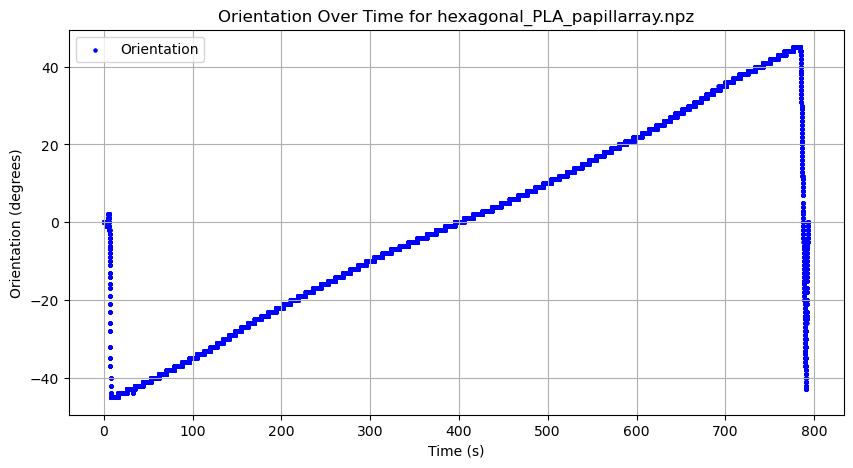

In [2]:
# Select a dataset to plot
sensor_type = 'PapillArray'
material = 'PLA'
geometry = 'hexagonal'

file_name = None
for name, data in dataset[sensor_type].items():
    if data['material'] == material and data['geometry'] == geometry:
        file_name = name
        break


# Extract orientation and times
angle = data['angle']
times = data['times']

# Plot the orientation
plt.figure(figsize=(10, 5))
plt.scatter(times, angle, label='Orientation', color='blue', s=5)
plt.xlabel('Time (s)')
plt.ylabel('Orientation (degrees)')
plt.title(f'Orientation Over Time for {file_name}')
plt.legend()
plt.grid(True)
plt.show()


Statistics for Xela circular PLA at -27°:
Number of points: 697
Mean z-force: -1.04N
Std z-force: 2.40N
Min z-force: -10.98N
Max z-force: 1.19N
Statistics for PapillArray circular PLA at -27°:
Number of points: 615
Mean z-force: -1.00N
Std z-force: 2.57N
Min z-force: -11.28N
Max z-force: 1.31N


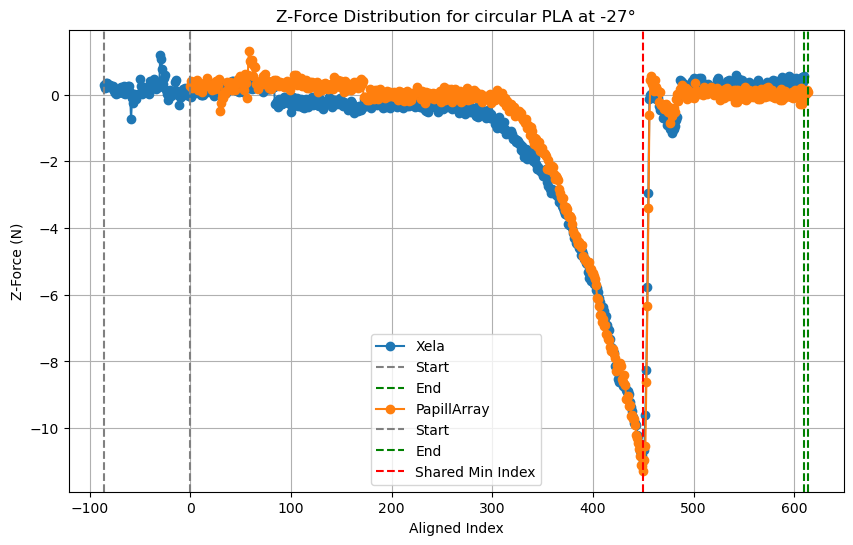

In [3]:
def plot_z_force_distribution(dataset, sensor_types, geometry, material, angle):
    """
    Plot z-force distribution for specific sensors, geometry, material and angle
    
    Args:
        dataset: The loaded dataset
        sensor_types: ['Xela', 'PapillArray']
        geometry: 'cylinder', 'hexagon', or 'oblong'
        material: 'TPU' or 'PLA'
        angle: The specific angle to plot
    """
    plt.figure(figsize=(10, 6))
    
    min_indices = []
    z_forces_list = []
    labels = []
    
    for sensor_type in sensor_types:
        data = None
        for file_name, file_data in dataset[sensor_type].items():
            if file_data['geometry'] == geometry and file_data['material'] == material:
                data = file_data
                break

        if data is None:
            print(f"Data not found for {sensor_type} with the specified parameters.")
            continue
        
        ft_values = data['ft_values']
        angles = data['angle']
        
        indices = np.where(np.array(angles) == angle)[0]

        # Extract z-forces for the specified angle
        z_forces = ft_values[indices, 2]
        
        # Find the index of the minimum point
        min_index = np.argmin(z_forces)
        min_indices.append(min_index)
        z_forces_list.append(z_forces)
        labels.append(sensor_type)
        
        # Print statistics
        print(f"Statistics for {sensor_type} {geometry} {material} at {angle}°:")
        print(f"Number of points: {len(z_forces)}")
        print(f"Mean z-force: {np.mean(z_forces):.2f}N")
        print(f"Std z-force: {np.std(z_forces):.2f}N")
        print(f"Min z-force: {np.min(z_forces):.2f}N")
        print(f"Max z-force: {np.max(z_forces):.2f}N")
    
    min_index_global = min(min_indices)
    
    for i, z_forces in enumerate(z_forces_list):
        shift = min_indices[i] - min_index_global
        aligned_indices = np.arange(len(z_forces)) - shift
        plt.plot(aligned_indices, z_forces, marker='o', label=f'{labels[i]}')
        plt.axvline(x=-shift, color='gray', linestyle='--', label='Start')  # Start index
        plt.axvline(x=len(z_forces) - 1 - shift, color='green', linestyle='--', label='End')
    
    plt.axvline(x=min_index_global, color='red', linestyle='--', label='Shared Min Index')

    # Plot
    plt.title(f'Z-Force Distribution for {geometry} {material} at {angle}°')
    plt.xlabel('Aligned Index')
    plt.ylabel('Z-Force (N)')
    plt.grid(True)
    plt.legend()
    plt.show()


angle = -27
plot_z_force_distribution(dataset, ['Xela', 'PapillArray'], 'circular', 'PLA', angle)

# Align Two Sensors

In [4]:
def identify_poking_period(z_forces):
    """Identify the start, peak locations of the poking period in z-force data."""
    if len(z_forces) == 0:
        return 0, 0
    threshold = 0.1 * np.max(np.abs(z_forces))
    start_idx = np.argmax(np.abs(z_forces) > threshold)
    peak_idx = np.argmax(np.abs(z_forces))
    return start_idx, peak_idx

def process_alignment_pipeline(dataset, sensor_types, geometry, material):
    """
    Combined pipeline:
    1. Align sensors by matching z-force targets (creates selected_mask)
    2. Verify alignment consistency
    3. Clean dataset by applying mask
    """
    print(f"\n{'='*50}")
    print(f"Processing {geometry} {material}...")
    
    sensor_files = {}
    for sensor_type in sensor_types:
        for file_name, file_data in dataset[sensor_type].items():
            if file_data['geometry'] == geometry and file_data['material'] == material:
                sensor_files[sensor_type] = file_data
                break

    if len(sensor_files) < 2:
        print(f"Skipping: Data incomplete for {sensor_types}")
        return

    # Initialize masks
    for sensor_type in sensor_types:
        if 'selected_mask' not in sensor_files[sensor_type]:
            sensor_files[sensor_type]['selected_mask'] = np.zeros(len(sensor_files[sensor_type]['angle']), dtype=bool)


    angles_data = sensor_files[sensor_types[0]]['angle']
    unique_angles = np.unique(angles_data)

    # FT-Z target values (-4N to -10N in 0.25N steps)
    ftz_targets = np.arange(-5, -10.1, -0.25)

    for angle in unique_angles:
        sensor_ftz_candidates = {}
        available_indices_map = {} 

        # Extract poking phase
        for sensor_type in sensor_types:
            data = sensor_files[sensor_type]
            # Find indices for this angle
            indices = np.where(np.array(data['angle']) == angle)[0]
            
            if len(indices) == 0: continue

            z_forces = data['ft_values'][indices, 2]

            # Identify poking period
            start_idx, peak_idx = identify_poking_period(z_forces)
            
            poking_indices = indices[start_idx:peak_idx+1]
            poking_values = z_forces[start_idx:peak_idx+1]
            
            sensor_ftz_candidates[sensor_type] = poking_values
            available_indices_map[sensor_type] = poking_indices

        # Pair matching 
        paired_indices = {sensor: [] for sensor in sensor_types}

        for target in ftz_targets:
            current_match = {}
            valid_match = True
            
            # Try to find best match
            for sensor in sensor_types:
                if sensor not in sensor_ftz_candidates or len(sensor_ftz_candidates[sensor]) == 0:
                    valid_match = False
                    break
                
                # Find closest point
                vals = sensor_ftz_candidates[sensor]
                global_idxs = available_indices_map[sensor]
                
                unused_mask = np.isin(global_idxs, paired_indices[sensor], invert=True)
                if not np.any(unused_mask):
                    valid_match = False
                    break
                    
                unused_vals = vals[unused_mask]
                unused_global_idxs = global_idxs[unused_mask]
                
                # Find closest value
                distances = np.abs(unused_vals - target)
                best_local_idx = np.argmin(distances)
                
                # Threshold for a "good" match 
                if distances[best_local_idx] > 0.5: 
                    # valid_match = False 
                    pass 

                current_match[sensor] = unused_global_idxs[best_local_idx]

            if valid_match and len(current_match) == len(sensor_types):
                for sensor, idx in current_match.items():
                    paired_indices[sensor].append(idx)

        # Update masks based on pairs found
        for sensor_type in sensor_types:
            if paired_indices[sensor_type]:
                sensor_files[sensor_type]['selected_mask'][paired_indices[sensor_type]] = True

    print("Verifying alignment...")
    mismatch_found = False
    
    # Store original lengths
    original_lengths = {st: len(sensor_files[st]['ft_values']) for st in sensor_types}
    
    # Check lengths per angle
    for angle in unique_angles:
        lengths = []
        for sensor_type in sensor_types:
            data = sensor_files[sensor_type]
            mask = data['selected_mask']
            angle_indices = np.where(data['angle'] == angle)[0]
            selected_count = np.sum(mask[angle_indices])
            lengths.append(selected_count)
            
        if len(set(lengths)) > 1:
            print(f"  WARNING: Length mismatch at angle {angle}: {lengths}")
            mismatch_found = True

    if not mismatch_found:
        print("  Verification Successful: All angles have matching data points across sensors.")

    print("Cleaning dataset...")
    final_lengths = {}
    
    for sensor_type in sensor_types:
        data = sensor_files[sensor_type]
        mask = data['selected_mask']
        
        arrays_to_clean = [
            'ft_values', 'sensor_matrices_force', 
            'sensor_matrices_displacement', 'end_effector_poses', 'angle'
        ]
        
        for arr_name in arrays_to_clean:
            if arr_name in data:
                data[arr_name] = np.array(data[arr_name])[mask]
        
        final_lengths[sensor_type] = len(data['ft_values'])

    # --- Statistics ---
    print(f"Alignment Complete for {geometry} {material}:")
    for sensor_type in sensor_types:
        deleted = original_lengths[sensor_type] - final_lengths[sensor_type]
        kept_pct = (final_lengths[sensor_type]/original_lengths[sensor_type]*100)
        print(f"  {sensor_type}: {original_lengths[sensor_type]} -> {final_lengths[sensor_type]} entries ({kept_pct:.2f}% kept)")

sensor_types = ['Xela', 'PapillArray']
for geometry in ['circular', 'hexagonal', 'square']:
    for material in ['PLA', 'TPU']:
        process_alignment_pipeline(dataset, sensor_types, geometry, material)


Processing circular PLA...
Verifying alignment...
  Verification Successful: All angles have matching data points across sensors.
Cleaning dataset...
Alignment Complete for circular PLA:
  Xela: 64508 -> 1911 entries (2.96% kept)
  PapillArray: 56296 -> 1911 entries (3.39% kept)

Processing circular TPU...
Verifying alignment...
  Verification Successful: All angles have matching data points across sensors.
Cleaning dataset...
Alignment Complete for circular TPU:
  Xela: 79593 -> 1911 entries (2.40% kept)
  PapillArray: 73544 -> 1911 entries (2.60% kept)

Processing hexagonal PLA...
Verifying alignment...
  Verification Successful: All angles have matching data points across sensors.
Cleaning dataset...
Alignment Complete for hexagonal PLA:
  Xela: 85077 -> 1911 entries (2.25% kept)
  PapillArray: 79367 -> 1911 entries (2.41% kept)

Processing hexagonal TPU...
Verifying alignment...
  Verification Successful: All angles have matching data points across sensors.
Cleaning dataset...
Ali

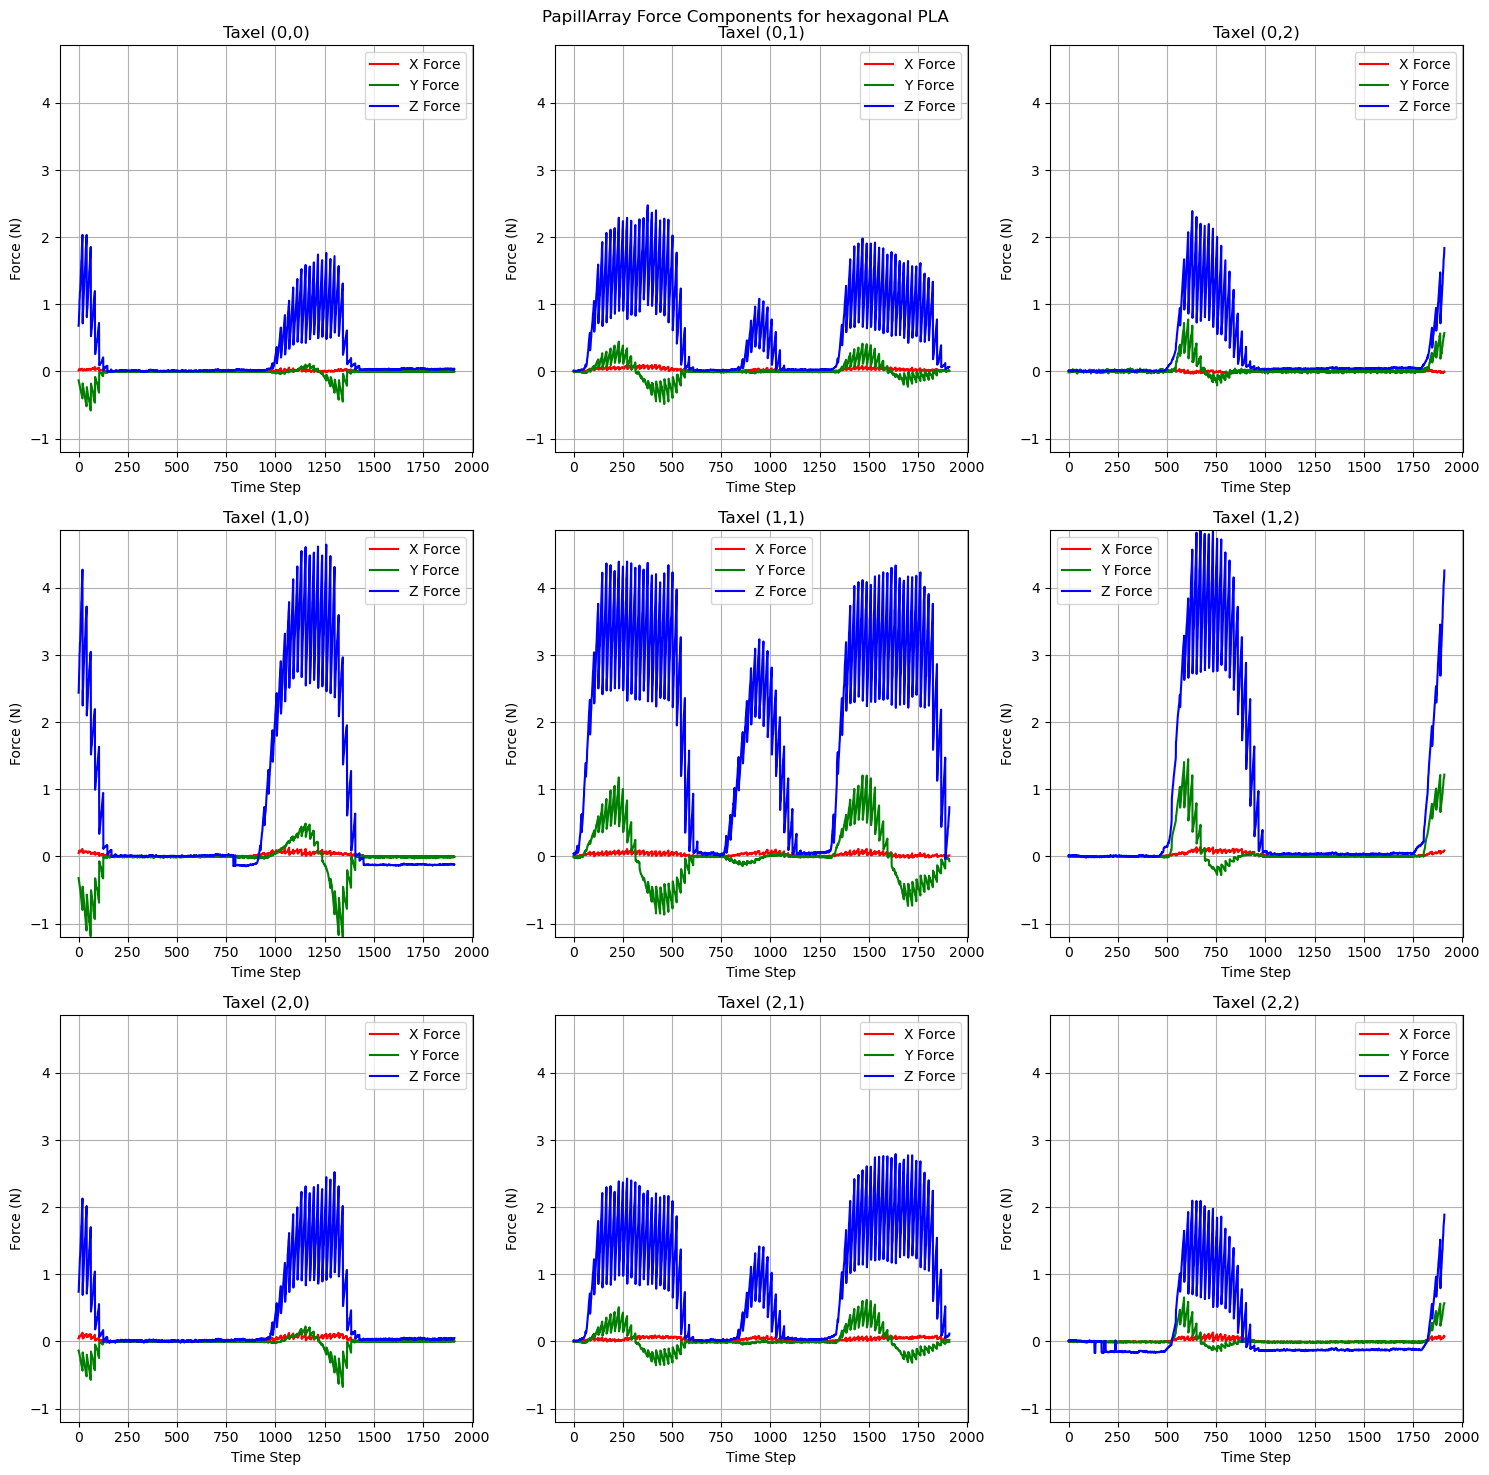

In [5]:
def plot_papillarray_forces(dataset, geometry, material):
    """
    Plot PapillArray tactile forces (x, y, z) for all indices with consistent y-axis limits.
    """
    # Find PapillArray data
    papillarray_data = None
    for file_name, data in dataset['PapillArray'].items():
        if data['geometry'] == geometry and data['material'] == material:
            papillarray_data = data
            break
    
    if papillarray_data is None:
        print("PapillArray data not found")
        return
    
    # Get force data
    forces = papillarray_data['sensor_matrices_force'] # Shape: (n, 3, 3, 3)
    
    # Determine global y-axis limits
    y_min = forces.min()
    y_max = forces.max()
    
    # Create 3x3 subplot
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    fig.suptitle(f'PapillArray Force Components for {geometry} {material}')
    
    # Plot each taxel's forces
    for i in range(3):
        for j in range(3):
            ax = axes[i, j]
            ax.plot(forces[:, i, j, 0], label='X Force', color='r')
            ax.plot(forces[:, i, j, 1], label='Y Force', color='g')
            ax.plot(forces[:, i, j, 2], label='Z Force', color='b')
            
            ax.set_title(f'Taxel ({i},{j})')
            ax.set_xlabel('Time Step')
            ax.set_ylabel('Force (N)')
            ax.set_ylim([y_min, y_max]) 
            ax.grid(True)
            ax.legend()
    
    plt.tight_layout()
    plt.show()

plot_papillarray_forces(dataset, 'hexagonal', 'PLA')


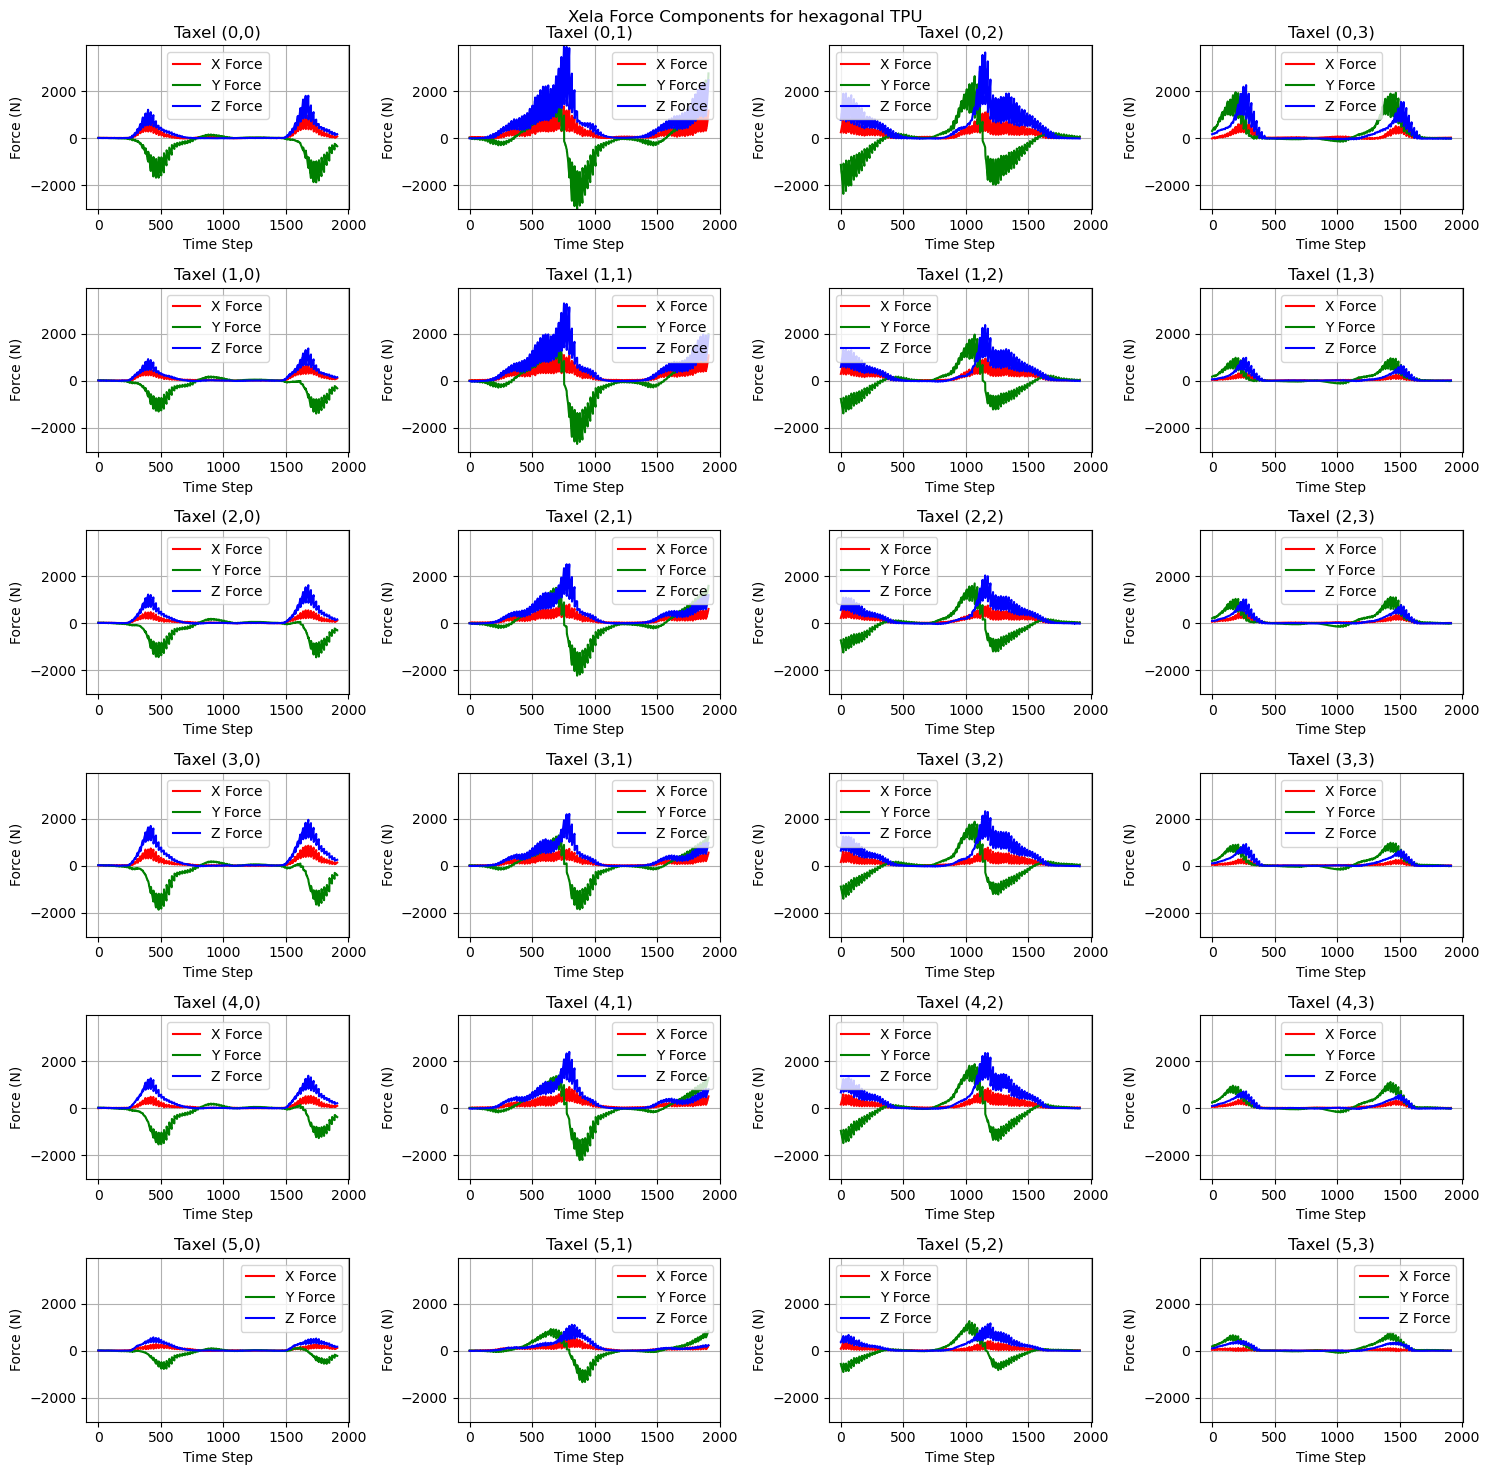

In [6]:

def plot_xela_forces(dataset, geometry, material):
    """
    Plot PapillArray tactile forces (x, y, z) for all indices with consistent y-axis limits.
    """
    # Find PapillArray data
    xela_data = None
    for file_name, data in dataset['Xela'].items():
        if data['geometry'] == geometry and data['material'] == material:
            xela_data = data
            break
    
    if xela_data is None:
        print("Xela data not found")
        return
    
    # Get force data
    forces = xela_data['sensor_matrices_force'] # Shape: (n, 3, 3, 3)
    
    # Determine global y-axis limits
    y_min = forces.min()
    y_max = forces.max()
    
    # Create 3x3 subplot
    fig, axes = plt.subplots(6, 4, figsize=(15, 15))
    fig.suptitle(f'Xela Force Components for {geometry} {material}')
    for i in range(6):
        for j in range(4):
            ax = axes[i, j]
            # Plot x, y, z forces for current taxel
            ax.plot(forces[:, i, j, 0], label='X Force', color='r')
            ax.plot(forces[:, i, j, 1], label='Y Force', color='g')
            ax.plot(forces[:, i, j, 2], label='Z Force', color='b')
            
            ax.set_title(f'Taxel ({i},{j})')
            ax.set_xlabel('Time Step')
            ax.set_ylabel('Force (N)')
            ax.set_ylim([y_min, y_max]) 
            ax.grid(True)
            ax.legend()
    
    plt.tight_layout()
    plt.show()

plot_xela_forces(dataset, 'hexagonal', 'TPU')
